In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS
from training_configuration import PATHWAYS_2A, CONTEXTS_FEATURES_2A

data = "dream_cytof"
filename = "evaluate_all_figure2a"

df = pd.concat(
    pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0).assign(model=model)
    for model in PATHWAYS_2A
)

In [3]:
val_df = df[df.dataset == "val"]
val_df.features.fillna("None", inplace=True)

In [5]:
val_df[val_df.ref == "DMM"].groupby(["model", "context"]).rmse.mean()

model                           context                    
EGFR_MAPK__logobs               cytof_init                     0.527314
                                cytof_init_plus_intr           0.514161
                                cytof_init_plus_lb             0.516484
                                cytof_init_plus_pEGFR          0.531810
                                cytof_init_plus_tEGFR          0.544537
                                cytof_init_plus_tEGFR_pEGFR    0.505191
EGFR_MAPK__logobs_fegfr_aggavg  cytof_init                     0.592362
                                cytof_init_plus_intr           0.555761
                                cytof_init_plus_lb             0.487568
                                cytof_init_plus_pEGFR          0.501446
                                cytof_init_plus_tEGFR          0.527104
                                cytof_init_plus_tEGFR_pEGFR    0.521335
Name: rmse, dtype: float64

Load results from Fig 1A

In [7]:
model1 = "EGFR_MAPK__logobs"
data = "dream_cytof"
filename1 = "evaluate_all_figure1a"

df1 = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model1, data=data, filename=filename1), index_col=0)
df1.model.fillna(model1, inplace=True)  # single model investigated in this batch of runs

val_df1 = df1[df1.dataset == "val"]

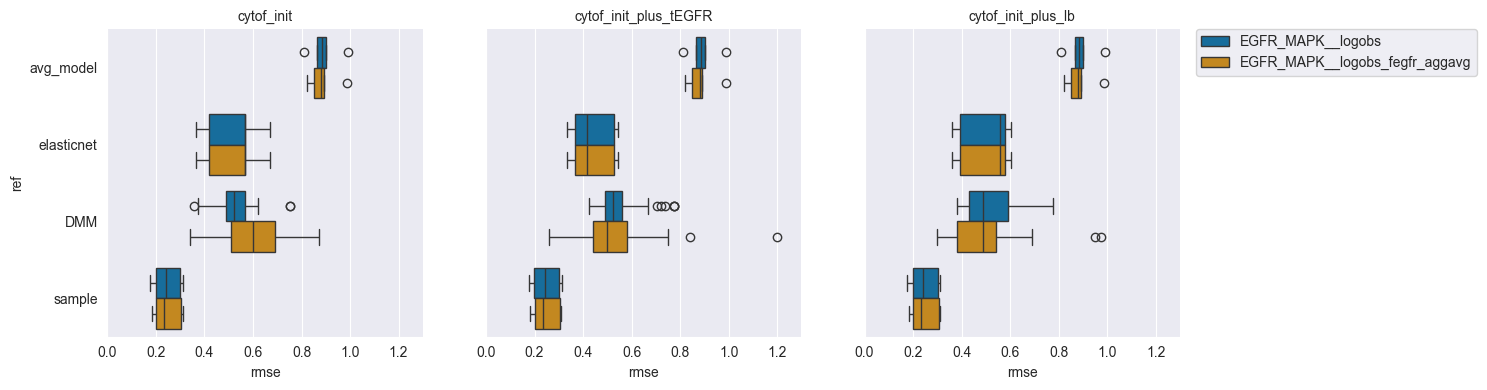

In [38]:
palette = {
    "cytof_init": "cyan",
    "cytof_init_plus_tEGFR": "navy",
    "cytof_init_plus_lb": "lime",
    "cytof_init_plus_intr": "red"
}

g = sns.FacetGrid(
    val_df[
        (val_df.ref.isin(["avg_model", "elasticnet", "DMM", "sample"])) &
        (val_df.context.isin(["cytof_init", "cytof_init_plus_tEGFR", "cytof_init_plus_lb",]))
    ],
    col="context",
    col_order=[
        "cytof_init", "cytof_init_plus_tEGFR", "cytof_init_plus_lb",
    ],
    height=4,
    aspect=1
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="rmse",
    order=["avg_model", "elasticnet", "DMM", "sample",],
    hue="model",
    hue_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_fegfr_aggavg"],
    palette=sns.color_palette("colorblind"),
)
# Titles without prefixes
g.set_titles(row_template="{row_name}", col_template="{col_name}")

plt.xlim([0, 1.3])
plt.subplots_adjust(wspace=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [64]:
comp_df = val_df[
        (val_df.ref.isin(["avg_model", "elasticnet", "DMM", "sample"])) &
        (val_df.context.isin(["cytof_init", "cytof_init_plus_tEGFR", "cytof_init_plus_lb",]))
    ]

print(comp_df.shape)
comp_df = pd.concat(
    [comp_df, val_df1[(val_df1.context == "multimodal") & (val_df1.features == "best_RFE_10_permute") & (val_df1.ref.isin(["DMM", "elasticnet"]))]]
)

comp_df

(390, 16)


,dataset,ref,model,samples,context,features,n_hidden,depth,l1reg_inflater_output,l2reg_inflater_output,recon_loss,inflater_output_reg_epoch,job,n_epoch,inflater_bound,rmse
400,val,DMM,EGFR_MAPK__logobs,EVSAT,cytof_init_plus_tEGFR,RFE_10_permute,2.0,0.0,0.01,0.0,0.01,200.0,0.0,500.0,3.0,0.774680
401,val,DMM,EGFR_MAPK__logobs,EVSAT,cytof_init_plus_tEGFR,RFE_10_permute,2.0,0.0,0.01,0.0,0.01,200.0,1.0,500.0,3.0,0.776358
402,val,DMM,EGFR_MAPK__logobs,EVSAT,cytof_init_plus_tEGFR,RFE_10_permute,2.0,0.0,0.01,0.0,0.01,200.0,2.0,500.0,3.0,0.509846
404,val,DMM,EGFR_MAPK__logobs,EVSAT,cytof_init_plus_tEGFR,RFE_10_permute,2.0,0.0,0.01,0.0,0.01,200.0,4.0,500.0,3.0,0.586309
405,val,DMM,EGFR_MAPK__logobs,EVSAT,cytof_init_plus_tEGFR,RFE_10_permute,2.0,0.0,0.01,0.0,0.01,200.0,5.0,500.0,3.0,0.649845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,val,elasticnet,EGFR_MAPK__logobs,MCF7,multimodal,best_RFE_10_permute,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.471146
177,val,elasticnet,EGFR_MAPK__logobs,UACC3199,multimodal,best_RFE_10_permute,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.395423
171,val,elasticnet,EGFR_MAPK__logobs,HCC1500,multimodal,best_RFE_10_permute,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.552332
168,val,elasticnet,EGFR_MAPK__logobs,EVSAT,multimodal,best_RFE_10_permute,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.615871


In [65]:
import numpy as np

comp_df["group"] = np.where(
    comp_df["ref"].isin(["avg_model", "sample"]),
    comp_df["ref"],  # case 1: avg_model / sample
    np.where(
        comp_df["ref"] == "elasticnet",
        comp_df["ref"] + "_" + comp_df["context"],  # case 2: elasticnet -> ref+context
        comp_df["model"] + "_" + comp_df["ref"] + "_" + comp_df["context"]  # case 3: all others
    )
)
comp_df.group.unique()

array(['EGFR_MAPK__logobs_DMM_cytof_init_plus_tEGFR',
       'EGFR_MAPK__logobs_DMM_cytof_init_plus_lb',
       'EGFR_MAPK__logobs_DMM_cytof_init', 'avg_model',
       'elasticnet_cytof_init_plus_tEGFR', 'elasticnet_cytof_init',
       'elasticnet_cytof_init_plus_lb', 'sample',
       'EGFR_MAPK__logobs_fegfr_aggavg_DMM_cytof_init_plus_tEGFR',
       'EGFR_MAPK__logobs_fegfr_aggavg_DMM_cytof_init_plus_lb',
       'EGFR_MAPK__logobs_fegfr_aggavg_DMM_cytof_init',
       'EGFR_MAPK__logobs_DMM_multimodal', 'elasticnet_multimodal'],
      dtype=object)

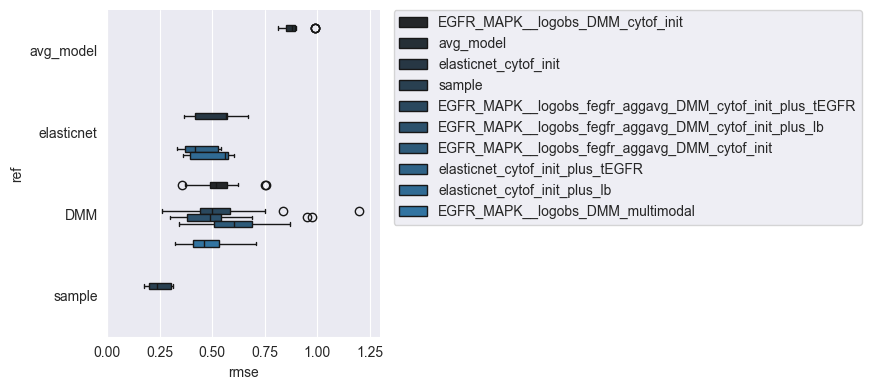

In [57]:
palette = {
    "cytof_init": "cyan",
    "cytof_init_plus_tEGFR": "navy",
    "cytof_init_plus_lb": "lime",
    "cytof_init_plus_intr": "red"
}

g = sns.FacetGrid(
    comp_df[
        ((comp_df.model == "EGFR_MAPK__logobs_fegfr_aggavg") & (comp_df.context.isin(["cytof_init_plus_tEGFR", "cytof_init_plus_lb"]))) |
        (comp_df.context.isin(["cytof_init", "multimodal"]))
    ],
    height=4,
    aspect=1
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="rmse",
    order=["avg_model", "elasticnet", "DMM", "sample",],
    hue="group",
    # hue="ref",
    # hue_order=["avg_model", "elasticnet", "DMM", "sample",],
    # palette={
    #     "avg_model": "pink",
    #     "elasticnet": "green",
    #     "DMM": "cornflowerblue",
    #     "sample": "darkgray",
    # },
)
# Titles without prefixes
g.set_titles(row_template="{row_name}", col_template="{col_name}")

plt.xlim([0, 1.3])
plt.subplots_adjust(wspace=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

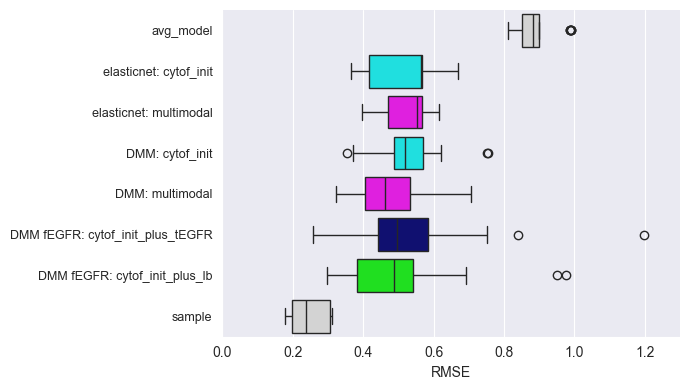

In [68]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- choose exactly the combos you want to display ---
want_elasticnet_contexts = ["cytof_init", "multimodal"]
want_dmm_logobs = ["cytof_init", "multimodal"]
want_dmm_fegfr = ["cytof_init_plus_tEGFR", "cytof_init_plus_lb"]

df = comp_df.copy()

# Build a single display label per row
def mk_label(r):
    if r["ref"] == "avg_model":
        return "avg_model"
    if r["ref"] == "sample":
        return "sample"
    if r["ref"] == "elasticnet":
        if r["context"] in want_elasticnet_contexts:
            return f"elasticnet: {r['context']}"
        else:
            return None
    if r["ref"] == "DMM":
        if r["model"] == "EGFR_MAPK__logobs" and r["context"] in want_dmm_logobs:
            return f"DMM: {r['context']}"
        if r["model"] == "EGFR_MAPK__logobs_fegfr_aggavg" and r["context"] in want_dmm_fegfr:
            return f"DMM fEGFR: {r['context']}"
        return None
    # drop anything else
    return None

df["display_group"] = df.apply(mk_label, axis=1)
plot_df = df.dropna(subset=["display_group"]).copy()

# Order exactly as requested
order = [
    "avg_model",
    "elasticnet: cytof_init", "elasticnet: multimodal",
    "DMM: cytof_init", "DMM: multimodal",
    "DMM fEGFR: cytof_init_plus_tEGFR", "DMM fEGFR: cytof_init_plus_lb",
    "sample",
]

# Map colors based on the context embedded in the label
ctx_color = {
    "cytof_init": "cyan",
    "cytof_init_plus_tEGFR": "navy",
    "cytof_init_plus_lb": "lime",
    "cytof_init_plus_intr": "red",
    "multimodal": "magenta",   # pick something distinct
}
def label_color(lbl):
    # try to pull the context after the colon
    if ":" in lbl:
        ctx = lbl.split(": ", 1)[1]
        return ctx_color.get(ctx, "lightgray")
    # singleton categories without context
    return "lightgray"

palette = {lbl: label_color(lbl) for lbl in order}

# --- plot: no hue, so no empty subgroup space ---
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=plot_df,
    y="display_group",
    x="rmse",
    order=order,
    palette=palette,
)
plt.yticks(fontsize=9)
plt.xlabel("RMSE")
plt.ylabel("")
plt.xlim(0, 1.3)
sns.despine()
plt.tight_layout()
plt.savefig("RMSE_fig2a_relevant_contexts.svg")

# Let's zoom in on DMMs only (regressors are not affected by model choice), comparing model/context combos

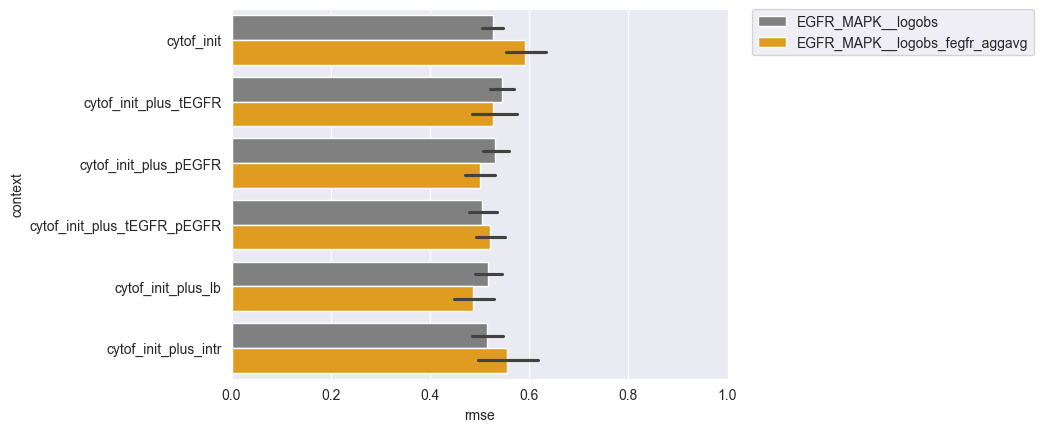

In [69]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_fegfr_aggavg": "orange",
    "EGFR_MAPK__logobs_fegfr_aggavg_pobs": "red",
}

sns.barplot(
    val_df[val_df.ref == "DMM"],
    y="context",
    x="rmse",
    order=[
        "cytof_init",
        "cytof_init_plus_tEGFR",
        "cytof_init_plus_pEGFR",
        "cytof_init_plus_tEGFR_pEGFR",
        "cytof_init_plus_lb",
        "cytof_init_plus_intr",
    ],
    hue="model",
    palette=palette
)
plt.xlim([0, 1])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

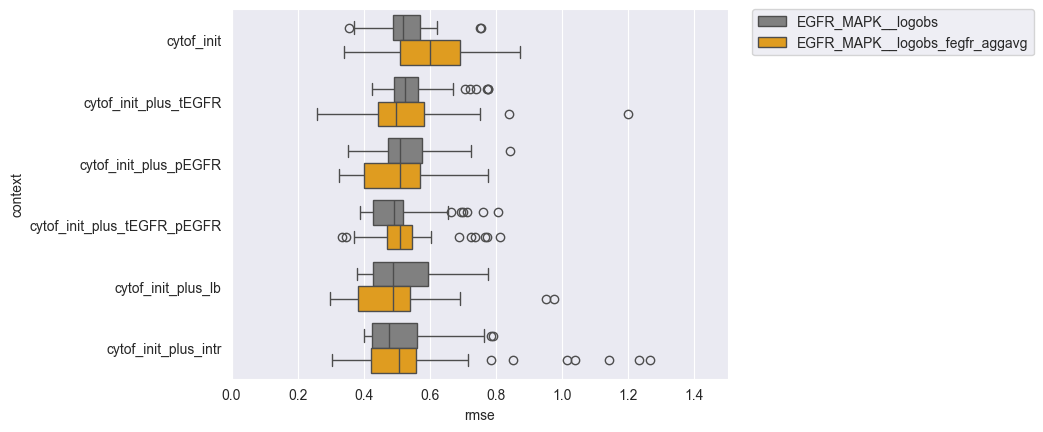

In [70]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_fegfr_aggavg": "orange",
    "EGFR_MAPK__logobs_fegfr_aggavg_pobs": "red",
}

sns.boxplot(
    val_df[val_df.ref == "DMM"],
    y="context",
    x="rmse",
    order=[
        "cytof_init",
        "cytof_init_plus_tEGFR",
        "cytof_init_plus_pEGFR",
        "cytof_init_plus_tEGFR_pEGFR",
        "cytof_init_plus_lb",
        "cytof_init_plus_intr"
    ],
    hue="model",
    palette=palette
)
plt.xlim([0, 1.5])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# If we look at `samples`-split, we notice we get better on BT-20, UACC-3199 and MCF-7, which were the worst performing CVS, but we get worse on both cell-lines with low EGFR levels (EVSA-T and HCC-1500).

In [73]:
val_df[
    ((val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs")) |
    ((val_df.context == "cytof_init_plus_tEGFR") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg"))
].groupby(["ref", "model", "context", "samples"]).rmse.mean()

ref         model                           context                samples 
DMM         EGFR_MAPK__logobs               cytof_init             BT20        0.570556
                                                                   EVSAT       0.457633
                                                                   HCC1500     0.518661
                                                                   MCF7        0.540066
                                                                   UACC3199    0.549653
            EGFR_MAPK__logobs_fegfr_aggavg  cytof_init_plus_tEGFR  BT20        0.489085
                                                                   EVSAT       0.599069
                                                                   HCC1500     0.556826
                                                                   MCF7        0.483950
                                                                   UACC3199    0.506592
avg_model   EGFR_MAPK__logobs               

(0.0, 1.0)

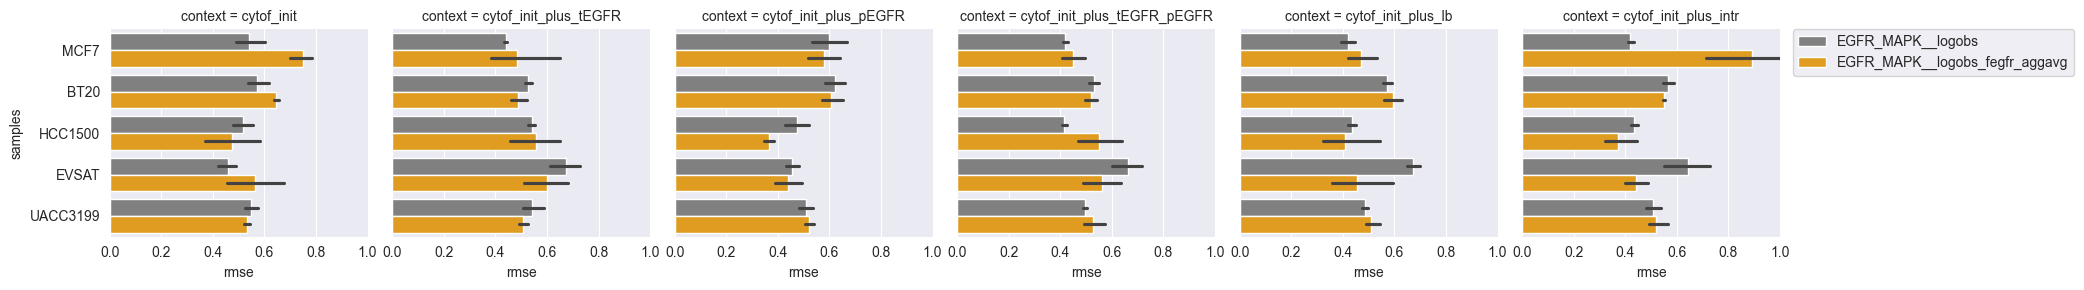

In [71]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_fegfr_aggavg": "orange",
}

g = sns.FacetGrid(
    val_df[val_df.ref == "DMM"],
    col="context",
    col_order=[
        "cytof_init",
        "cytof_init_plus_tEGFR",
        "cytof_init_plus_pEGFR",
        "cytof_init_plus_tEGFR_pEGFR",
        "cytof_init_plus_lb",
        "cytof_init_plus_intr"
    ]
)

g.map_dataframe(
    sns.barplot,
    x="rmse",
    y="samples",
    order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"],
    hue="model",
    hue_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_fegfr_aggavg"],
    palette=palette
)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.xlim([0, 1])

In [ ]:
sns.boxplot(
    val_df[
        ((val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs")) |
        ((val_df.context == "cytof_init_plus_tEGFR") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg"))
    ],
    y="ref",
    order=["avg_model", "elasticnet", "DMM", "sample"],
    x="rmse",
    hue="model",
)

In [78]:
from scipy import stats

target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
    val_df[(val_df.context == "cytof_init_plus_lb") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg") & (val_df.ref == "DMM")].sort_values(by=["samples", "job"]).rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="greater")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=904.0, p=0.004696


Adding LB subtype and switching model produces a significant improvement

In [75]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init_plus_lb") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "elasticnet")].sort_values(by=["samples"]).rmse.values,
    val_df[(val_df.context == "cytof_init_plus_lb") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg") & (val_df.ref == "DMM")].groupby("samples").rmse.mean().values,
]
stat, p = stats.wilcoxon(*groups, alternative="greater")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=9.0, p=0.4062


But even cytof_init_plus_LB does not perform better than regressors trained on that context...

In [ ]:
sns.boxplot(
    val_df[
        ((val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs")) |
        ((val_df.context == "cytof_init_plus_lb") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg"))
    ],
    y="ref",
    order=["avg_model", "elasticnet", "DMM", "sample"],
    x="rmse",
    hue="model",
)

# Let's restrict to `__logobs_fegr_aggavg` and compare with baselines and regressors

In [ ]:
context_palette = {
    "cytof_init": "cyan",
    "cytof_init_plus_tEGFR": "green",
    "cytof_init_plus_pEGFR": "gold",
    "cytof_init_plus_tEGFR_pEGFR": "lime",
    "cytof_init_plus_lb": "magenta",
    "cytof_init_plus_intr": "cyan"
}

g = sns.FacetGrid(
    val_df[val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg"],
    height=6,
    aspect=2
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
    hue="context",
    hue_order=[
        "cytof_init",
        "cytof_init_plus_tEGFR",
        "cytof_init_plus_pEGFR",
        "cytof_init_plus_tEGFR_pEGFR",
        "cytof_init_plus_lb",
        "cytof_init_plus_intr"
    ],
    palette=context_palette
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [ ]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric):
    for context in df['context'].unique():
        context_data = df[df['context'] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}")

In [ ]:
kruskal_wallis_groups(
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_fegfr_aggavg"]))],
    "rmse",
    "model"
)

# No clear improvement (anymore, using 1-2 `l1reg_inflater_output`) when changing model per-se from `__logobs` to `__logobs_fegfr_aggavg` (above). Clear significant worsening when going to `fegfr_aggavg_pobs` (below)

# But is there an improvement in going from `__logobs` with `cytof_init` to `__logobs_fegfr_aggavg` with `cytof_init_plus_tEGFR` or `cytof_init_plus_lb`? Or `__logobs_fegfr_aggavg_pobs` with `cytof_init_plus_tEGFR_pEGFR`? No, yes, yes/no. Only significant improvement seems to be with `lb` augmentation!?

In [ ]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by="job").rmse.values,
    val_df[(val_df.context == "cytof_init_plus_tEGFR") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg") & (val_df.ref == "DMM")].sort_values(by="job").rmse.values,
]
stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

In [ ]:
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

In [ ]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by="job").rmse.values,
    val_df[(val_df.context == "cytof_init_plus_lb") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg") & (val_df.ref == "DMM")].sort_values(by="job").rmse.values,
]
stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

In [ ]:
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

In [ ]:
val_df.groupby(["model", "context"]).rmse.mean()